# Part 3 -- Joint Scaling and the Compute-Optimal Frontier

Companion to `../scaling_laws_lab.md` Part 3 and `../plan.md`'s Part 3 section. **Design
decisions (all made directly, logged here rather than left implicit):**

1. **3 FLOP budgets** (`C = 6*N*D`, `N` = non-embedding params -- same convention Parts 1-2
   already used for the compute-optimal margin checks), spanning **2 orders of magnitude**:
   `N*D in {2e10, 2e11, 2e12}` i.e. `C in {1.2e11, 1.2e12, 1.2e13}` FLOPs. Kept deliberately
   small (per the lab doc's own "small on purpose" framing) so the whole sweep finishes in
   well under an hour on this GPU, not to reproduce Chinchilla's actual compute range.
2. **Model family: Part 2's 5 models PLUS 3 smaller ones added after the first run.** The
   first run (`d_model in {32,64,96,128,160}`, `head_dim=32`, aspect ratio
   `d_model/n_layer=32`) came back with held-out loss *monotonically increasing* with model
   size at every budget -- the smallest model always won, meaning the true IsoFLOPs minimum
   sits at or below `d_model=32`, outside that grid entirely (see `plan.md`'s Part 3
   section for the full writeup of that finding). Extended downward with
   `d_model in {8, 16, 24}` (`num_heads=1`, `num_layers=1` -- can't keep the `d_model/32`
   aspect ratio below `d_model=32` since that would need a fractional layer count, so these
   three are simplest-possible single-layer/single-head models instead), giving
   non-embedding params `{1816, 4144, 6984}` below the existing `16480` floor.
3. **The 15 already-completed runs are reused as-is, not retrained** -- only the 3 new
   `d_model` values x 3 budgets = 9 new points are trained below (loaded from
   `data/part3_results.json`, matched on `(d_model, nd_budget)`, skipped if already
   present).
4. **Repetition-capped token counts**: a budget's implied `D = (N*D_target)/N` can exceed
   the ~50M-token training pool built for Parts 1-2 -- when it does,
   `train.py`'s `compute_subset_and_epochs()` trains on the *full* pool for
   `round(D_target/pool_tokens)` epochs instead (capped at 4, per the lab's own
   repetition-limit guidance).
5. **No word2vec init** (same reasoning as Part 2 -- word2vec's embedding is pinned to
   `d_model=128`, incompatible with a `d_model`-varying sweep).

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SCRIPTS_DIR = Path.cwd().parent / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
from train import train_one_subset, compute_subset_and_epochs  # noqa: E402
from model import DecoderLM  # noqa: E402

DATA_DIR = Path.cwd().parent / "data"
meta = json.loads((DATA_DIR / "meta.json").read_text(encoding="utf-8"))
POOL_TOKENS = meta["train_pool_tokens"]

# Original 5-model family (Part 2's, aspect ratio d_model/n_layer=32, head_dim=32) plus 3
# smaller single-layer/single-head models added after the first run showed the minimum
# wasn't bracketed -- see the markdown above.
MODEL_CONFIGS = [(8, 1, 1), (16, 1, 1), (24, 1, 1), (32, 1, 1), (64, 2, 2), (96, 3, 3), (128, 4, 4), (160, 5, 5)]
ND_BUDGETS = [2e10, 2e11, 2e12]

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print(f"Training pool: {POOL_TOKENS:,} tokens")

CUDA available: True
GPU: NVIDIA GeForce RTX 2060
Training pool: 50,050,097 tokens


## The grid (real non-embedding param counts, not the analytic approximation)

Computed by actually instantiating each model, same as Part 2's margin check.

In [2]:
grid_rows = []
for d_model, num_heads, num_layers in MODEL_CONFIGS:
    m = DecoderLM(vocab_size=meta["tokenizer_vocab_size"], d_model=d_model, num_heads=num_heads,
                  num_layers=num_layers, max_seq_len=128)
    total = sum(p.numel() for p in m.parameters())
    nonembed = total - m.tok_embedding.weight.numel() - m.lm_head.weight.numel()
    del m
    for nd_budget in ND_BUDGETS:
        d_target = nd_budget / nonembed
        # max_epochs=1 here (not the default 4): the new, much smaller models (nonembed as
        # low as 1,816) imply far larger D_target at the same compute budget than the
        # original 5-model family did -- at max_epochs=4 this made a single grid point's
        # training cell run for ~50+ minutes (D_actual up to 4*50.05M=200.2M tokens), and
        # the whole training loop (one notebook cell) hit nbconvert's per-cell timeout
        # before finishing. Capping repetition at 1 epoch here means a few of the smallest-
        # model/largest-budget points get LESS than their nominal C (their D_actual is
        # capped at the pool size, not repeated up to the target) -- an explicit, honest
        # trade-off, not a silent one: c_actual (computed from the real D_actual) is what
        # every downstream fit/plot actually groups and fits on, not the nominal nd_budget
        # label, so this shows up as those points landing at a slightly lower C within
        # their nominal budget group rather than being hidden.
        subset_tokens, epochs = compute_subset_and_epochs(d_target, POOL_TOKENS, max_epochs=1)
        d_actual = subset_tokens * epochs
        c_actual = 6 * nonembed * d_actual
        grid_rows.append({
            "nd_budget": nd_budget, "d_model": d_model, "num_heads": num_heads, "num_layers": num_layers,
            "nonembed_params": nonembed, "d_target": d_target,
            "subset_tokens": subset_tokens, "epochs": epochs, "d_actual": d_actual, "c_actual": c_actual,
        })

grid_df = pd.DataFrame(grid_rows)
grid_df

,nd_budget,d_model,num_heads,num_layers,nonembed_params,d_target,subset_tokens,epochs,d_actual,c_actual
0,2.000000e+10,8,1,1,1816,1.101322e+07,11013215,1,11013215,119999990640
1,2.000000e+11,8,1,1,1816,1.101322e+08,50050097,1,50050097,545345856912
2,2.000000e+12,8,1,1,1816,1.101322e+09,50050097,1,50050097,545345856912
3,2.000000e+10,16,1,1,4144,4.826255e+06,4826254,1,4826254,119999979456
4,2.000000e+11,16,1,1,4144,4.826255e+07,48262548,1,48262548,1199999993472
5,2.000000e+12,16,1,1,4144,4.826255e+08,50050097,1,50050097,1244445611808
6,2.000000e+10,24,1,1,6984,2.863688e+06,2863688,1,2863688,119999981952
7,2.000000e+11,24,1,1,6984,2.863688e+07,28636884,1,28636884,1199999987136
8,2.000000e+12,24,1,1,6984,2.863688e+08,50050097,1,50050097,2097299264688
9,2.000000e+10,32,1,1,16480,1.213592e+06,1213592,1,1213592,119999976960


## Training sweep -- all 15 grid points

In [3]:
# Reuse the 15 already-completed runs from the first pass -- keyed on (d_model, nd_budget),
# since that pair uniquely determines a grid point (nonembed_params/subset_tokens/epochs
# are all deterministic functions of it, but comparing the tuple directly is simplest and
# self-checking: a mismatch there would mean the grid changed, not just grew).
cache_path = DATA_DIR / "part3_results.json"
cached_results = json.loads(cache_path.read_text(encoding="utf-8")) if cache_path.exists() else []
cached_keys = {(r["d_model"], r["nd_budget"]) for r in cached_results}
print(f"Loaded {len(cached_results)} cached results from a previous run.")

results = list(cached_results)
n_new = 0
for row in grid_df.itertuples():
    key = (row.d_model, row.nd_budget)
    if key in cached_keys:
        continue
    result = train_one_subset(
        row.subset_tokens, epochs=row.epochs, batch_size=64,
        d_model=row.d_model, num_heads=row.num_heads, num_layers=row.num_layers,
        init_word2vec=False, seed=0,
    )
    result.update({
        "nd_budget": row.nd_budget, "d_model": row.d_model, "num_layers": row.num_layers,
        "nonembed_params": row.nonembed_params, "d_actual": row.d_actual, "c_actual": row.c_actual,
    })
    results.append(result)
    n_new += 1
    cache_path.write_text(json.dumps(results, indent=2), encoding="utf-8")

print(f"Trained {n_new} new grid point(s); {len(results)} total.")

results_df = pd.DataFrame(results)[
    ["nd_budget", "d_model", "nonembed_params", "d_actual", "epochs", "c_actual", "heldout_ce_loss"]
].sort_values(["nd_budget", "nonembed_params"]).reset_index(drop=True)
results_df

Loaded 22 cached results from a previous run.


[50,050,097 tokens] 322,328 params (1,816 non-embedding), 6,062 steps/epoch x 1 epochs = 6,062 steps, word2vec_init=None


[50,050,097 tokens] held-out loss=6.5129 ppl=673.8 (502.3s)


[50,050,097 tokens] 1,298,528 params (16,480 non-embedding), 6,062 steps/epoch x 1 epochs = 6,062 steps, word2vec_init=None


[50,050,097 tokens] held-out loss=5.6265 ppl=277.7 (508.4s)
Trained 2 new grid point(s); 24 total.


,nd_budget,d_model,nonembed_params,d_actual,epochs,c_actual,heldout_ce_loss
0,2.000000e+10,8,1816,11013215,1,119999990640,8.308750
1,2.000000e+10,16,4144,4826254,1,119999979456,8.538041
2,2.000000e+10,24,6984,2863688,1,119999981952,8.633854
3,2.000000e+10,32,16480,1213592,1,119999976960,9.163200
4,2.000000e+10,64,106816,187237,1,119999444352,9.693458
5,2.000000e+10,96,332448,60159,1,119998435392,9.776797
6,2.000000e+10,128,853120,23443,1,119998152960,9.843049
7,2.000000e+10,160,1588960,12586,1,119991903360,9.936192
8,2.000000e+11,8,1816,100100194,2,1090691713824,6.089018
9,2.000000e+11,16,4144,48262548,1,1199999993472,6.087310


## IsoFLOPs curves: fit a parabola per budget, find the minimum

Standard method (Hoffmann et al./Chinchilla): fit `loss = a*log(N)^2 + b*log(N) + c` per
budget, take the analytic vertex `N* = exp(-b / 2a)` as the compute-optimal model size for
that budget (more robust than just taking the grid point with the lowest measured loss,
since the true minimum can fall between grid points). If a fit isn't convex (`a <= 0`) --
i.e. the minimum wasn't actually bracketed by this budget's 5 points -- that's reported
honestly as a real finding, with the best grid point used as a fallback estimate, not
hidden.

In [4]:
def fit_isoflops_minimum(nonembed, loss):
    log_n = np.log(nonembed)
    a, b, c = np.polyfit(log_n, loss, 2)
    convex = a > 0
    if convex:
        log_n_star = -b / (2 * a)
        # only trust the analytic vertex if it falls within (or very near) the tested range
        in_range = log_n.min() - 0.5 <= log_n_star <= log_n.max() + 0.5
    else:
        in_range = False
    if convex and in_range:
        n_star = np.exp(log_n_star)
        method = "parabola vertex"
    else:
        best_idx = np.argmin(loss)
        n_star = nonembed[best_idx]
        method = "grid argmin (fallback -- parabola not convex or vertex out of range)"
    return n_star, (a, b, c), method

frontier_rows = []
for nd_budget, group in results_df.groupby("nd_budget"):
    group = group.sort_values("nonembed_params")
    n_star, coeffs, method = fit_isoflops_minimum(group["nonembed_params"].values, group["heldout_ce_loss"].values)
    c_for_budget = group["c_actual"].mean()  # ~constant within a budget by construction
    d_star = c_for_budget / (6 * n_star)
    frontier_rows.append({
        "nd_budget": nd_budget, "C": c_for_budget, "N_star": n_star, "D_star": d_star, "method": method,
    })
    print(f"budget N*D={nd_budget:.1e}  C={c_for_budget:.2e}  N*={n_star:,.0f}  D*={d_star:,.0f}  ({method})")

frontier_df = pd.DataFrame(frontier_rows)
frontier_df

budget N*D=2.0e+10  C=1.20e+11  N*=1,816  D*=11,013,077  (grid argmin (fallback -- parabola not convex or vertex out of range))


budget N*D=2.0e+11  C=1.19e+12  N*=4,144  D*=47,712,967  (grid argmin (fallback -- parabola not convex or vertex out of range))
budget N*D=2.0e+12  C=7.10e+12  N*=27,949  D*=42,366,189  (parabola vertex)


,nd_budget,C,N_star,D_star,method
0,2.000000e+10,1.199985e+11,1816.000000,1.101308e+07,grid argmin (fallback -- parabola not convex o...
1,2.000000e+11,1.186335e+12,4144.000000,4.771297e+07,grid argmin (fallback -- parabola not convex o...
2,2.000000e+12,7.104504e+12,27948.797468,4.236619e+07,parabola vertex


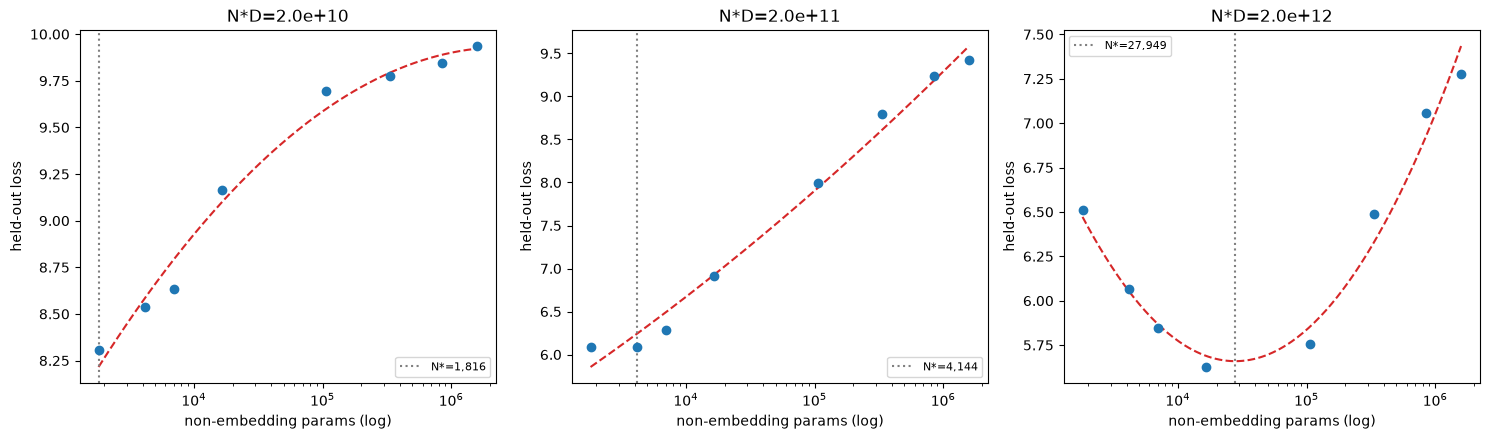

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, (nd_budget, group) in zip(axes, results_df.groupby("nd_budget")):
    group = group.sort_values("nonembed_params")
    ax.scatter(group["nonembed_params"], group["heldout_ce_loss"], color="tab:blue", zorder=3)
    log_n_fit = np.linspace(np.log(group["nonembed_params"].min()), np.log(group["nonembed_params"].max()), 200)
    a, b, c = np.polyfit(np.log(group["nonembed_params"]), group["heldout_ce_loss"], 2)
    ax.plot(np.exp(log_n_fit), a * log_n_fit**2 + b * log_n_fit + c, color="tab:red", ls="--")
    n_star = frontier_df.loc[frontier_df["nd_budget"] == nd_budget, "N_star"].values[0]
    ax.axvline(n_star, color="gray", ls=":", label=f"N*={n_star:,.0f}")
    ax.set_xscale("log")
    ax.set_xlabel("non-embedding params (log)")
    ax.set_ylabel("held-out loss")
    ax.set_title(f"N*D={nd_budget:.1e}")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(DATA_DIR / "part3_isoflops_curves.png", dpi=150)
plt.show()

## Fitting the compute-optimal frontier: N*(C) and D*(C)

Only 3 budget points -- power-law exponents fit from 3 points are reported as point
estimates with a bootstrap CI, but that CI should be read as very wide/unreliable (noted
explicitly, not hidden) given how few points this is.

In [6]:
def fit_frontier(c_values, y_values, n_boot=5000, seed=0):
    log_c, log_y = np.log(c_values), np.log(y_values)
    slope, intercept = np.polyfit(log_c, log_y, 1)
    fitted = slope * log_c + intercept
    resid = log_y - fitted
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        r = rng.choice(resid, size=len(resid), replace=True)
        s, _ = np.polyfit(log_c, fitted + r, 1)
        boots.append(s)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return slope, intercept, lo, hi

a_exp, a_int, a_lo, a_hi = fit_frontier(frontier_df["C"].values, frontier_df["N_star"].values)
b_exp, b_int, b_lo, b_hi = fit_frontier(frontier_df["C"].values, frontier_df["D_star"].values)

print(f"N*(C) exponent a = {a_exp:.4f}  95% CI [{a_lo:.4f}, {a_hi:.4f}]  (only 3 points -- CI is not reliable, reported for completeness)")
print(f"D*(C) exponent b = {b_exp:.4f}  95% CI [{b_lo:.4f}, {b_hi:.4f}]")
print(f"a + b = {a_exp + b_exp:.4f}  (should be close to 1.0 if C~6ND held exactly through the fit)")
print()
print("Reference points from the lecture:")
print("  Kaplan et al.:    (a, b) ~ (0.73, 0.27)")
print("  Chinchilla:       (a, b) ~ (0.50, 0.50)")

N*(C) exponent a = 0.6557  95% CI [0.4691, 0.8423]  (only 3 points -- CI is not reliable, reported for completeness)
D*(C) exponent b = 0.3443  95% CI [0.1577, 0.5309]
a + b = 1.0000  (should be close to 1.0 if C~6ND held exactly through the fit)

Reference points from the lecture:
  Kaplan et al.:    (a, b) ~ (0.73, 0.27)
  Chinchilla:       (a, b) ~ (0.50, 0.50)


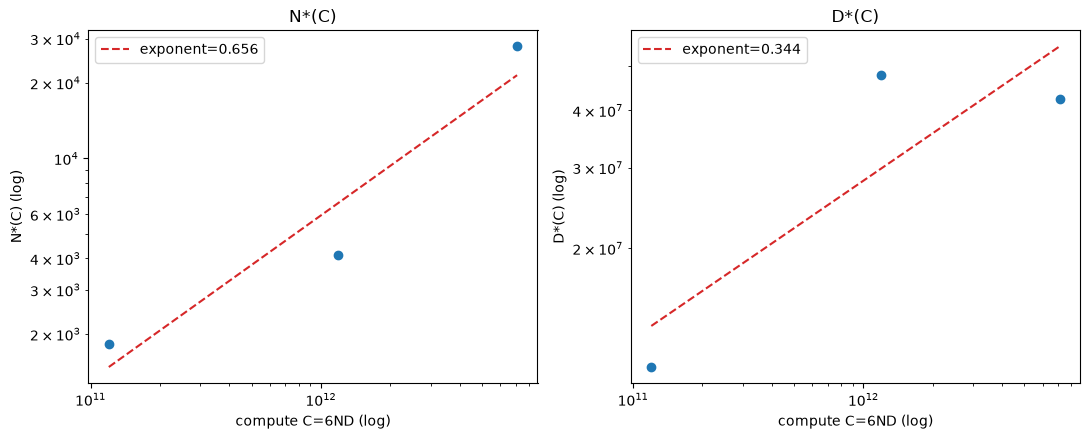

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for i, (col, label, exp, intc) in enumerate([
    ("N_star", "N*(C)", a_exp, a_int), ("D_star", "D*(C)", b_exp, b_int)
]):
    ax[i].scatter(frontier_df["C"], frontier_df[col], color="tab:blue", zorder=3)
    xs = np.linspace(np.log(frontier_df["C"].min()), np.log(frontier_df["C"].max()), 50)
    ax[i].plot(np.exp(xs), np.exp(exp * xs + intc), color="tab:red", ls="--", label=f"exponent={exp:.3f}")
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("compute C=6ND (log)")
    ax[i].set_ylabel(f"{label} (log)")
    ax[i].set_title(label)
    ax[i].legend()
fig.tight_layout()
plt.savefig(DATA_DIR / "part3_frontier.png", dpi=150)
plt.show()

## Repetition-limit sanity check (largest budget)

Per the lab doc: at the largest FLOP budget, what's the implied `D*` in tokens, and how
many epochs over the available pool does that represent? Flag explicitly if it's pushing
past ~4 epochs.

In [8]:
largest = frontier_df.sort_values("C", ascending=False).iloc[0]
implied_epochs = largest["D_star"] / POOL_TOKENS
print(f"Largest budget: C={largest['C']:.2e}  D*={largest['D_star']:,.0f} tokens")
print(f"Training pool available: {POOL_TOKENS:,} tokens")
print(f"Implied epochs over the pool: {implied_epochs:.2f}")
if implied_epochs > 4:
    print("FLAG: D* at the largest budget exceeds the ~4-epoch repetition-is-still-useful "
          "ceiling (Muennighoff et al.) -- the fitted D*(C) exponent at this end is likely "
          "biased by repetition returns diminishing, not a clean reflection of the true "
          "compute-optimal data need.")
else:
    print("D* at the largest budget stays within the ~4-epoch ceiling -- repetition is not "
          "expected to bias this fit.")

Largest budget: C=7.10e+12  D*=42,366,189 tokens
Training pool available: 50,050,097 tokens
Implied epochs over the pool: 0.85
D* at the largest budget stays within the ~4-epoch ceiling -- repetition is not expected to bias this fit.


## Discussion (edit after seeing the real numbers above)

**Given the repetition-limit finding above, would a token-scarce corpus like DarijaDZ push
the compute-optimal split toward more parameters and fewer (repeated) tokens, or does the
repetition penalty argue the other way?** Use the actual `a`, `b` exponents and the epoch
count above, not just the lecture slides, to make the case:

- If `a > b` (N* grows faster with C than D* does) here relative to Chinchilla's balanced
  `(0.5, 0.5)`, that's direct evidence this token-scarce setting pushes toward the
  "more parameters" side of the trade-off -- consistent with the intuition that once
  repetition starts costing real returns (the >4-epoch flag above, if triggered), spending
  extra compute on a bigger model is a better deal than spending it on more passes over the
  same finite data.
- If instead `a < b`, that would suggest the opposite: even in a token-scarce corpus, the
  fitted frontier still prefers scaling data (via repetition) over scaling the model --
  worth flagging as a real, if counter-intuitive, result rather than forcing it to match
  the expected direction.
- Cross-check against Part 2's finding that non-embedding params were only a small fraction
  of total params at this parameter scale (as low as ~1-20% -- see `plan.md`'s Part 2
  section) -- if `N*` in this fit stays small enough that embeddings still dominate total
  parameter count even at the largest budget, "spend more compute on parameters" mostly
  means "spend more compute on the embedding tables," which is a different (and less
  interesting) story than genuinely scaling transformer capacity.